In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/Users/mayurimamdi/Downloads/Books_Data_Clean.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1070 non-null   int64  
 1   Publishing Year      1069 non-null   float64
 2   Book Name            1047 non-null   object 
 3   Author               1070 non-null   object 
 4   language_code        1017 non-null   object 
 5   Author_Rating        1070 non-null   object 
 6   Book_average_rating  1070 non-null   float64
 7   Book_ratings_count   1070 non-null   int64  
 8   genre                1070 non-null   object 
 9   gross sales          1070 non-null   float64
 10  publisher revenue    1070 non-null   float64
 11  sale price           1070 non-null   float64
 12  sales rank           1070 non-null   int64  
 13  Publisher            1070 non-null   object 
 14  units sold           1070 non-null   int64  
dtypes: float64(5), int64(4), object(6)
mem

In [5]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In here, min of publishing year is -560, and I need to fix it 

In [6]:
df.shape

(1070, 15)

In [7]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [8]:
df = df[df['Publishing Year'] > 1800]

In [9]:
df.shape

(1050, 15)

In [10]:
df.isnull().sum()

index                   0
Publishing Year         0
Book Name              21
Author                  0
language_code          50
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

I need to delete all missing book name feature since there is no point keeping it as we need to do analysis on Books

In [11]:
df.dropna(subset='Book Name', inplace=True)

In [12]:
df.shape

(1029, 15)

In [13]:
df.duplicated().sum()

np.int64(0)

So no duplicates found

Lets see some Graphs

Text(0, 0.5, 'Frequency')

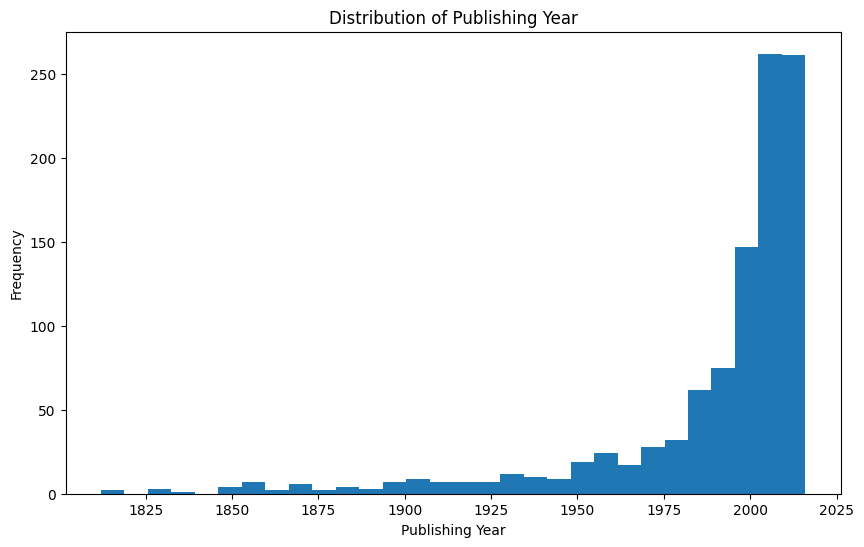

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df['Publishing Year'], bins=30)
plt.title('Distribution of Publishing Year')
plt.xlabel('Publishing Year')
plt.ylabel('Frequency')

In [15]:
df.groupby('Author')['Book_average_rating'].mean().sort_values(ascending=False)


Author
Bill Watterson                  4.650
Bill Watterson, G.B. Trudeau    4.610
J.R.R. Tolkien                  4.590
George R.R. Martin              4.560
Sarah J. Maas                   4.526
                                ...  
Audrey Niffenegger              3.230
Herman Koch, Sam Garrett        3.220
Stephen Crane                   3.210
P.D. James                      3.210
Sue Monk Kidd                   3.100
Name: Book_average_rating, Length: 708, dtype: float64

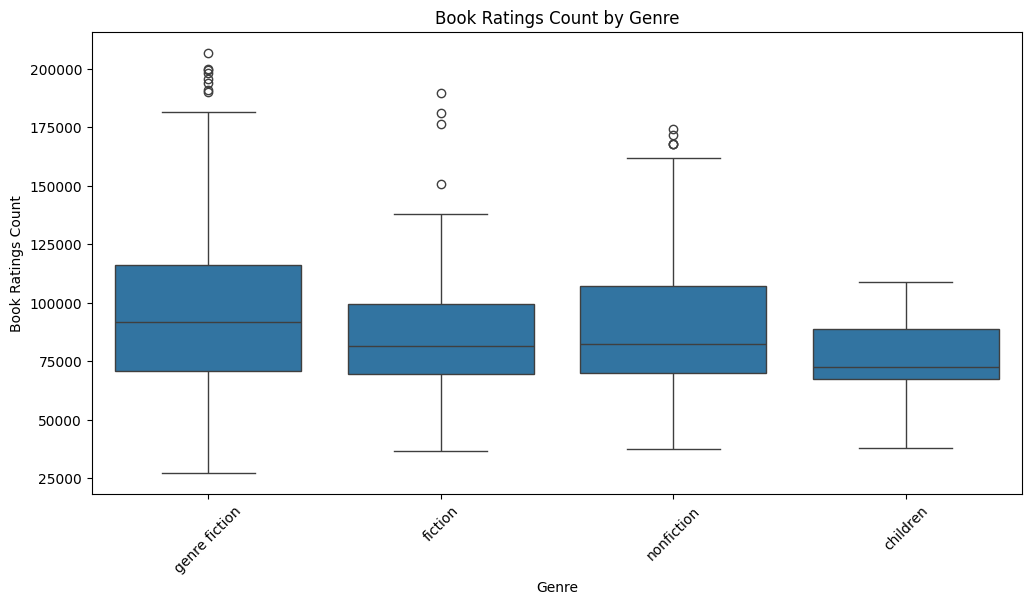

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(
    x='genre',
    y='Book_ratings_count',
    data=df
)

plt.title('Book Ratings Count by Genre')
plt.xlabel('Genre')
plt.ylabel('Book Ratings Count')
plt.xticks(rotation=45)

plt.show()

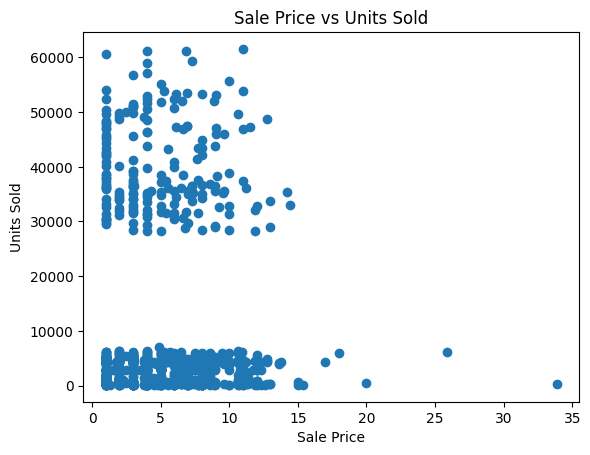

In [17]:
plt.scatter(df['sale price'], df['units sold'])
plt.title('Sale Price vs Units Sold')
plt.xlabel('Sale Price')
plt.ylabel('Units Sold')
plt.show()

<Axes: xlabel='language_code'>

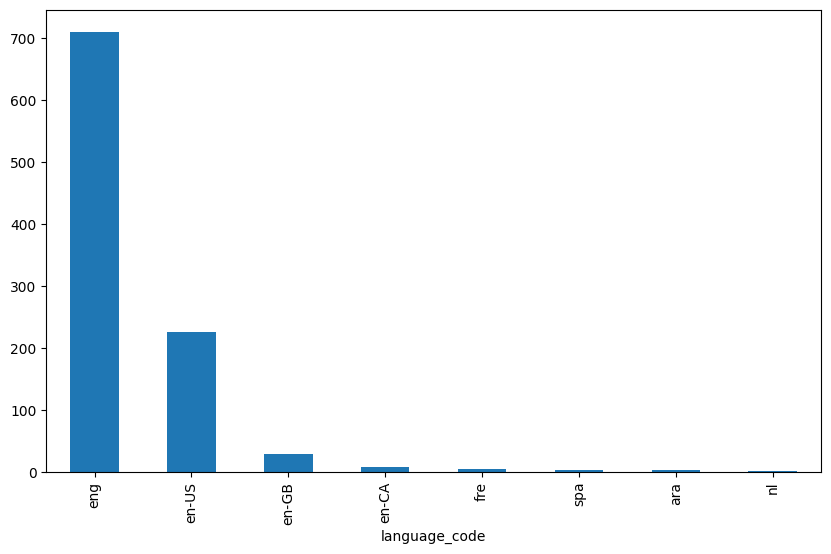

In [18]:
df['language_code'].value_counts().plot(kind='bar', figsize=(10, 6))


Text(0.5, 1.0, 'Gross sale by genre')

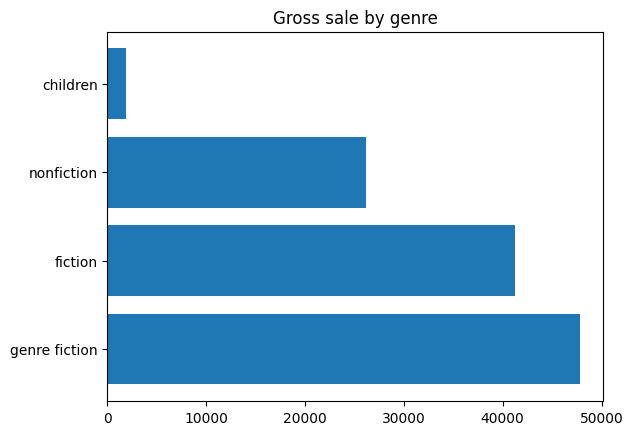

In [19]:
plt.barh(df['genre'], df['gross sales'])
plt.title("Gross sale by genre")

In [31]:
df.groupby('language_code')['units sold'].sum().reset_index()

,language_code,units sold
0,ara,7209
1,en-CA,12805
2,en-GB,241915
3,en-US,2341342
4,eng,7013134
5,fre,6545
6,nl,3969
7,spa,8459


In [25]:
lang = df['language_code'].value_counts()

([<matplotlib.patches.Wedge at 0x11f61ba60>,
 [Text(-0.8392425412053267, -0.7111061503258327, 'eng'),
  Text(0.9326664254441895, 0.583209515396618, 'en-US'),
  Text(0.21351966877321318, 1.0790780097133745, 'en-GB'),
  Text(0.08797315597847073, 1.0964765040014255, 'en-CA'),
  Text(0.049301182943857144, 1.0988946234104235, 'fre'),
  Text(0.028178527689019177, 1.0996390183043159, 'spa'),
  Text(0.014091020848788025, 1.0999097431750657, 'ara'),
  Text(0.0035228291459605803, 1.0999943589286303, 'nl')],
 [Text(-0.45776865883926904, -0.3878760819959087, '72%'),
  Text(0.5087271411513761, 0.31811428112542794, '23%'),
  Text(0.11646527387629808, 0.5885880052982042, '3%'),
  Text(0.04798535780643858, 0.5980780930916866, '1%'),
  Text(0.026891554333012983, 0.5993970673147764, '0%'),
  Text(0.015370106012192276, 0.599803100893263, '0%'),
  Text(0.007686011372066195, 0.5999507690045812, '0%'),
  Text(0.0019215431705239528, 0.5999969230519802, '0%')])

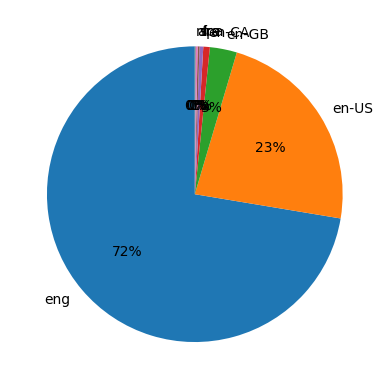

In [32]:
plt.pie(lang,labels=lang.index, autopct="%1.0f%%", startangle = 90)


In [35]:
df['Author'].value_counts()

Author
Stephen King                                              29
John Grisham                                              13
Nicholas Sparks                                           10
Charlaine Harris                                          10
Jim Butcher                                               10
                                                          ..
John Scalzi                                                1
Irma S. Rombauer, Marion Rombauer Becker, Ethan Becker     1
Joe Haldeman                                               1
Stephen King, Bettina Blanch Tyroller                      1
Dashiell Hammett                                           1
Name: count, Length: 708, dtype: int64

In [38]:
df.groupby('genre')['gross sales'].sum().reset_index()

,genre,gross sales
0,children,13902.22
1,fiction,119613.31
2,genre fiction,1540306.58
3,nonfiction,223033.93


In [42]:
top_10 = df.groupby('Author')['gross sales'].sum().sort_values(ascending=False).reset_index().head(10)

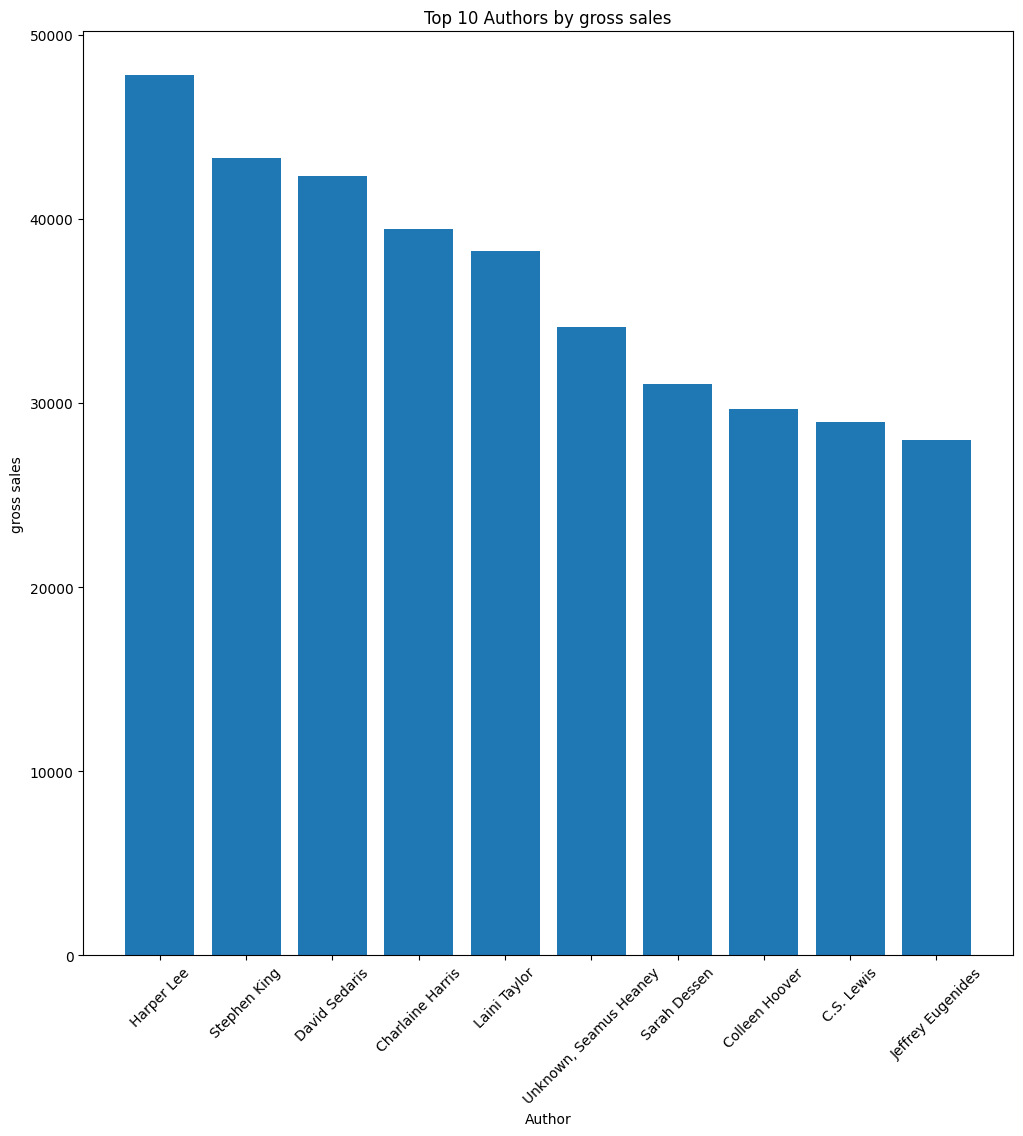

In [45]:
plt.figure(figsize=(12,12))
plt.bar(top_10['Author'], top_10['gross sales'])
plt.title("Top 10 Authors by gross sales")
plt.xlabel('Author')
plt.xticks(rotation=45)
plt.ylabel('gross sales')
plt.show()

In [46]:
df['Publisher '].value_counts()

Publisher 
Amazon Digital Services,  Inc.          579
Random House LLC                        119
Penguin Group (USA) LLC                  99
HarperCollins Publishers                 68
Hachette Book Group                      59
Simon and Schuster Digital Sales Inc     56
Macmillan                                41
HarperCollins Publishing                  4
HarperCollins Christian Publishing        4
Name: count, dtype: int64

In [51]:
Best_Publishers = df.groupby('Publisher ')['gross sales'].sum().sort_values(ascending=False).reset_index()

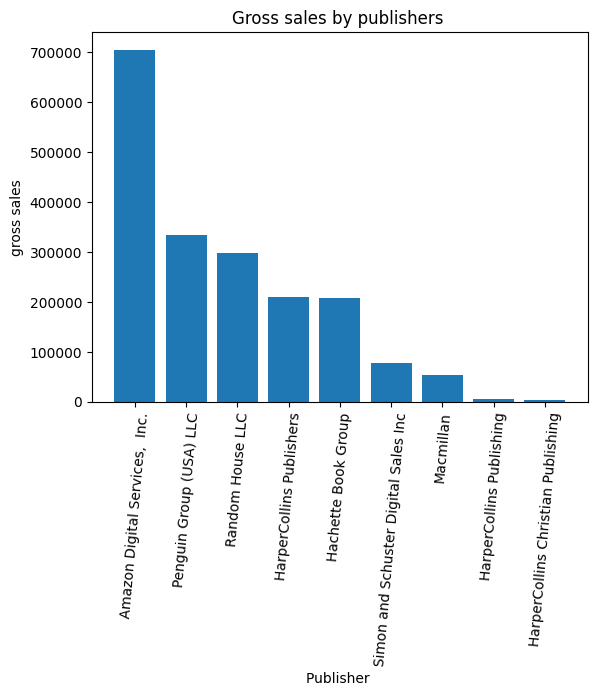

In [53]:
plt.bar(Best_Publishers['Publisher '], Best_Publishers['gross sales'])
plt.title("Gross sales by publishers ")
plt.xticks(rotation=85)
plt.xlabel('Publisher ')
plt.ylabel('gross sales')
plt.show()

In [60]:
publisher_revenue = df.groupby('Publisher ')['publisher revenue'].sum().sort_values(ascending=False).reset_index()

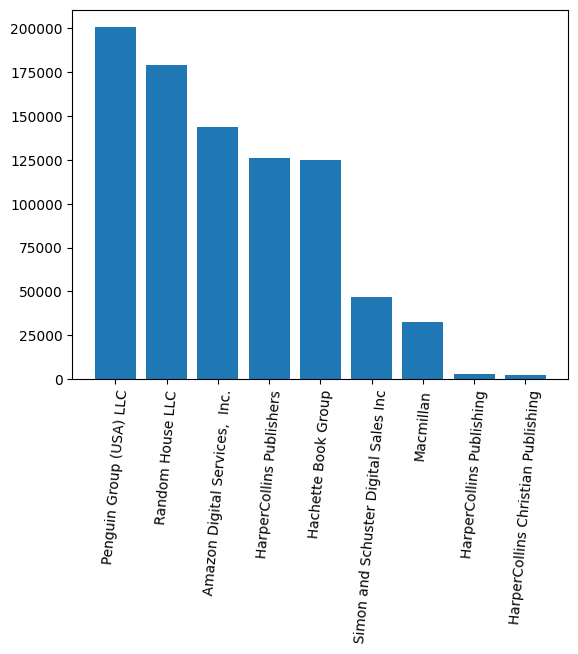

In [62]:
plt.bar(publisher_revenue['Publisher '], publisher_revenue['publisher revenue'])
plt.xticks(rotation=85)
plt.show()

In [54]:
df['Book Name'].value_counts()

Book Name
Persepolis                                2
The Awakening                             2
Beowulf                                   1
The Path of Daggers                       1
The Shell Seekers                         1
                                         ..
The Age of Innocence                      1
The Selfish Gene                          1
Year of Wonders: A Novel of the Plague    1
The Black Echo                            1
Tripwire                                  1
Name: count, Length: 1027, dtype: int64

In [48]:
df[df['Book Name'] == "Persepolis"]

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
297,297,2000.0,Persepolis,"Marjane Satrapi, Mattias Ripa",eng,Excellent,4.23,117103,genre fiction,1487.02,892.212,4.99,321,Random House LLC,298
933,933,2003.0,Persepolis,"Marjane Satrapi, Mattias Ripa, Blake Ferris, A...",en-US,Excellent,4.36,71353,nonfiction,108.90,0.000,0.99,1099,"Amazon Digital Services, Inc.",4320


why is the genre diff of the same book??

In [55]:
df[df['Book Name'] == 'The Awakening']

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
251,251,1899.0,The Awakening,Kate Chopin,eng,Intermediate,3.63,125474,genre fiction,371.25,0.00,0.99,275,"Amazon Digital Services, Inc.",375
696,696,2009.0,The Awakening,Kelley Armstrong,eng,Excellent,4.16,95026,genre fiction,761.10,456.66,6.45,802,Simon and Schuster Digital Sales Inc,36072


In [56]:
df['sales rank'].value_counts()

sales rank
524     3
1201    3
1199    3
376     3
770     3
       ..
454     1
455     1
457     1
458     1
1273    1
Name: count, Length: 840, dtype: int64

In [33]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750
